<a href="https://colab.research.google.com/github/LatiefDataVisionary/Eksperimen_SML_Lathif-Ramadhan/blob/main/preprocessing/Template_Eksperimen_MSML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Perkenalan Dataset**


Dataset ini berasal dari repositori **Kaggle** ([Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)) dan merupakan dataset standar yang digunakan oleh perusahaan telekomunikasi untuk memprediksi perilaku churn pelanggan.

**Konteks Bisnis:**
Mempertahankan pelanggan (retensi) jauh lebih hemat biaya daripada mengakuisisi pelanggan baru. Dataset ini berisi informasi tentang nasabah fiktif perusahaan telekomunikasi yang menyediakan layanan telepon rumah dan internet kepada 7.043 pelanggan di California.

**Deskripsi Kolom:**

1.  **Informasi Demografis:**
    *   `gender`: Jenis kelamin pelanggan (Male, Female).
    *   `SeniorCitizen`: Apakah pelanggan adalah lansia (1, 0).
    *   `Partner`: Apakah pelanggan memiliki pasangan (Yes, No).
    *   `Dependents`: Apakah pelanggan memiliki tanggungan (Yes, No).

2.  **Informasi Layanan:**
    *   `tenure`: Jumlah bulan pelanggan telah berlangganan.
    *   `PhoneService`: Apakah pelanggan memiliki layanan telepon (Yes, No).
    *   `MultipleLines`: Apakah pelanggan memiliki beberapa jalur telepon (Yes, No, No phone service).
    *   `InternetService`: Penyedia layanan internet (DSL, Fiber optic, No).
    *   `OnlineSecurity`: Layanan keamanan online (Yes, No, No internet service).
    *   `OnlineBackup`: Layanan pencadangan online (Yes, No, No internet service).
    *   `DeviceProtection`: Layanan perlindungan perangkat (Yes, No, No internet service).
    *   `TechSupport`: Layanan dukungan teknis (Yes, No, No internet service).
    *   `StreamingTV`: Layanan streaming TV (Yes, No, No internet service).
    *   `StreamingMovies`: Layanan streaming film (Yes, No, No internet service).

3.  **Informasi Akun & Pembayaran:**
    *   `Contract`: Jenis kontrak pelanggan (Month-to-month, One year, Two year).
    *   `PaperlessBilling`: Apakah pelanggan menggunakan penagihan tanpa kertas (Yes, No).
    *   `PaymentMethod`: Metode pembayaran (Electronic check, Mailed check, Bank transfer (automatic), Credit card (automatic)).
    *   `MonthlyCharges`: Biaya yang ditagihkan kepada pelanggan setiap bulan.
    *   `TotalCharges`: Total biaya yang ditagihkan kepada pelanggan.

4.  **Target Variable:**
    *   `Churn`: Apakah pelanggan berhenti berlangganan atau tidak (Yes, No).

# **2. Import Library**

In [ ]:
import os
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [ ]:
# Configuration
DATA_URL = "https://raw.githubusercontent.com/LatiefDataVisionary/Eksperimen_SML_Lathif-Ramadhan/refs/heads/main/Telco-Customer-Churn_Raw.csv"
OUTPUT_DIR = "data_clean"
OUTPUT_FILE = "telco_churn_cleaned.csv"

def load_data(url: str) -> pd.DataFrame:
    """
    Loads the dataset from a given URL.

    Args:
        url (str): The web URL or local path to the CSV file.
    Returns:
        pd.DataFrame: Loaded dataframe.
    """
    return pd.read_csv(url)

df = load_data(DATA_URL)
display(df.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


The Telco Customer Churn dataset typically includes various customer attributes and service usage information to predict whether a customer will churn (cancel their service). Common features often include:

*   **Demographic Information**: Gender, SeniorCitizen, Partner, Dependents.
*   **Account Information**: Tenure (how long the customer has been with the company), Contract type, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges.
*   **Services Information**: PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies.
*   **Target Variable**: Churn (Yes/No).

In [ ]:
# Display a concise summary of the DataFrame, including data types and non-null values
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
# Display descriptive statistics for numerical columns
display(df.describe())

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

/tmp/ipykernel_3472/2337071658.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='viridis')


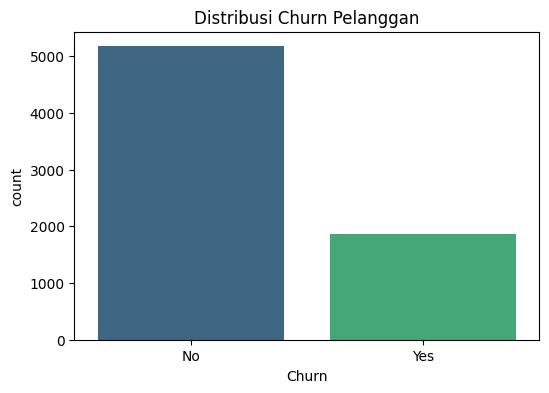

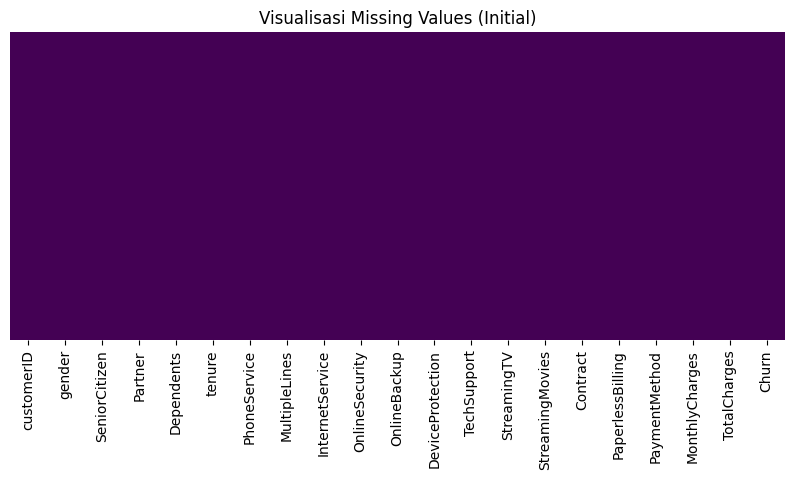

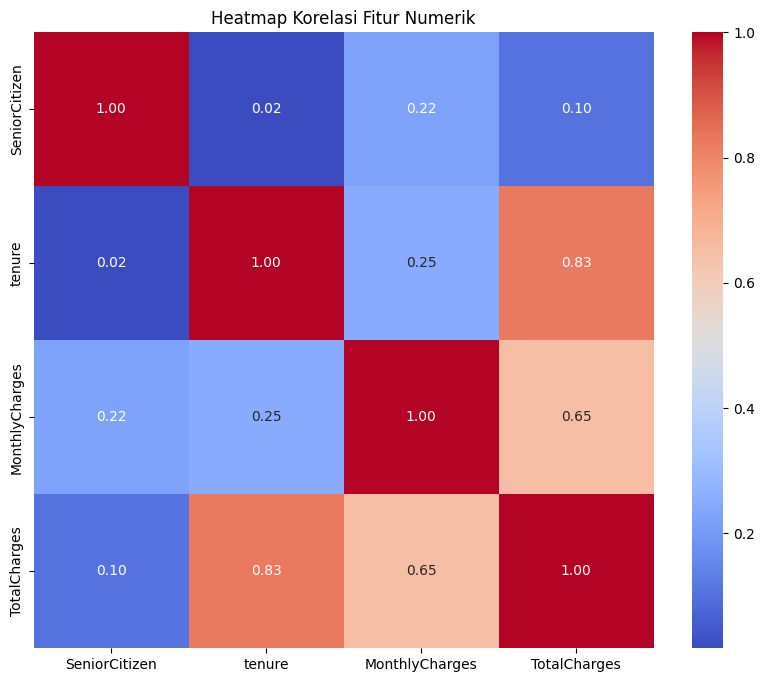

In [ ]:
def run_eda(df: pd.DataFrame):
    """
    Melakukan analisis data eksploratif dasar pada dataframe.

    Args:
        df (pd.DataFrame): Dataframe yang akan dianalisis.
    """
    # 1. Distribusi Target Variable (Churn)
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x='Churn', palette='viridis')
    plt.title('Distribusi Churn Pelanggan')
    plt.show()

    # 2. Visualisasi Missing Values
    plt.figure(figsize=(10, 4))
    sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
    plt.title('Visualisasi Missing Values (Initial)')
    plt.show()

    # 3. Korelasi antar fitur numerik
    # Konversi TotalCharges sementara ke numerik untuk korelasi
    temp_df = df.copy()
    temp_df['TotalCharges'] = pd.to_numeric(temp_df['TotalCharges'], errors='coerce')

    plt.figure(figsize=(10, 8))
    numeric_df = temp_df.select_dtypes(include=[np.number])
    sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
    plt.title('Heatmap Korelasi Fitur Numerik')
    plt.show()

run_eda(df)

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [ ]:
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Membersihkan dataset: penanganan tipe data dan penghapusan kolom yang tidak perlu.
    """
    df_clean = df.copy()

    # Hapus ID
    if 'customerID' in df_clean.columns:
        df_clean.drop(columns=['customerID'], inplace=True)

    # Konversi TotalCharges & Imputasi Median
    df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'].replace(' ', np.nan), errors='coerce')
    df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(df_clean['TotalCharges'].median())

    return df_clean

def split_dataset(df: pd.DataFrame, target='Churn', test_size=0.2):
    """
    Membagi data SEBELUM preprocessing untuk menghindari Data Leakage.
    """
    X = df.drop(columns=[target])
    y = df[target]
    return train_test_split(X, y, test_size=test_size, random_state=42, stratify=y)

def preprocess_pipeline(X_train, X_test, y_train, y_test, artifact_dir='models/artifacts'):
    """
    Pipeline transformasi modular: Fit pada Train, Transform pada Test.
    """
    if not os.path.exists(artifact_dir): os.makedirs(artifact_dir)

    X_train_proc, X_test_proc = X_train.copy(), X_test.copy()

    # 1. Target Encoding
    le_target = LabelEncoder()
    y_train_enc = le_target.fit_transform(y_train)
    y_test_enc = le_target.transform(y_test)
    joblib.dump(le_target, os.path.join(artifact_dir, 'target_encoder.joblib'))

    # 2. Identifikasi Kolom
    num_cols = X_train_proc.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = X_train_proc.select_dtypes(include=['object']).columns.tolist()

    # 3. Categorical Encoding (Label for Binary, OneHot for Multiclass)
    # Catatan: Menggunakan mapping sederhana untuk konsistensi produksi
    for col in cat_cols:
        le_feat = LabelEncoder()
        if X_train_proc[col].nunique() <= 2:
            X_train_proc[col] = le_feat.fit_transform(X_train_proc[col])
            X_test_proc[col] = le_feat.transform(X_test_proc[col])
        else:
            # Menggunakan get_dummies dengan penyesuaian kolom untuk menghindari mismatch
            X_train_proc = pd.get_dummies(X_train_proc, columns=[col], drop_first=True)
            X_test_proc = pd.get_dummies(X_test_proc, columns=[col], drop_first=True)
            # Sinkronisasi kolom X_test agar sama dengan X_train
            X_test_proc = X_test_proc.reindex(columns=X_train_proc.columns, fill_value=0)

    # 4. Feature Scaling (Hanya Fit pada Train!)
    scaler = StandardScaler()
    X_train_proc[num_cols] = scaler.fit_transform(X_train_proc[num_cols])
    X_test_proc[num_cols] = scaler.transform(X_test_proc[num_cols])
    joblib.dump(scaler, os.path.join(artifact_dir, 'scaler.joblib'))

    print(f"Preprocessing Selesai. Artifact disimpan di: {artifact_dir}")
    return X_train_proc, X_test_proc, y_train_enc, y_test_enc

# Eksekusi Rombakan
df_cleaned = clean_data(df)
X_train, X_test, y_train, y_test = split_dataset(df_cleaned)
X_train_final, X_test_final, y_train_final, y_test_final = preprocess_pipeline(X_train, X_test, y_train, y_test)

display(X_train_final.head())

Preprocessing Selesai. Artifact disimpan di: models/artifacts


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3738,1,-0.441773,0,0,0.102371,0,0,-0.521976,-0.263289,True,...,False,False,True,False,True,False,False,False,True,False
3151,1,-0.441773,1,1,-0.711743,1,0,0.337478,-0.504814,False,...,False,False,False,False,False,False,False,False,False,True
4860,1,-0.441773,1,1,-0.793155,0,0,-0.809013,-0.751213,True,...,True,False,False,False,False,False,True,False,False,True
3867,0,-0.441773,1,0,-0.263980,1,1,0.284384,-0.173699,False,...,False,False,True,False,True,False,True,True,False,False
3810,1,-0.441773,1,1,-1.281624,1,0,-0.676279,-0.990851,False,...,False,False,False,False,False,False,False,False,True,False


In [ ]:
def check_duplicates(df: pd.DataFrame):
    """
    Memeriksa dan menampilkan informasi mengenai data duplikat dalam dataset.

    Args:
        df (pd.DataFrame): Dataframe yang akan diperiksa.
    """
    duplicate_count = df.duplicated().sum()
    if duplicate_count > 0:
        print(f"Terdeteksi {duplicate_count} baris duplikat.")
        # Optional: Menghapus duplikat jika ditemukan
        # df.drop_duplicates(inplace=True)
    else:
        print("Tidak ditemukan data duplikat dalam dataset.")

check_duplicates(df)

Tidak ditemukan data duplikat dalam dataset.


In [ ]:
def preprocess_and_save_artifacts(df: pd.DataFrame, artifact_dir: str):
    """
    Melakukan preprocessing sekaligus menyimpan objek scaler dan encoder untuk kebutuhan inferensi.

    Args:
        df (pd.DataFrame): Dataframe yang sudah dibersihkan.
        artifact_dir (str): Direktori untuk menyimpan file joblib.
    Returns:
        pd.DataFrame: Dataframe yang siap untuk modeling.
    """
    df_processed = df.copy()

    if not os.path.exists(artifact_dir):
        os.makedirs(artifact_dir)

    # 1. Identifikasi kolom
    numeric_cols = df_processed.select_dtypes(include=['int64', 'float64']).columns.tolist()
    categorical_cols = df_processed.select_dtypes(include=['object']).columns.tolist()
    if 'Churn' in categorical_cols: categorical_cols.remove('Churn')

    # 2. Fit & Save Scaler
    scaler = StandardScaler()
    df_processed[numeric_cols] = scaler.fit_transform(df_processed[numeric_cols])
    joblib.dump(scaler, os.path.join(artifact_dir, 'scaler.joblib'))

    # 3. Fit & Save Target Encoder
    le = LabelEncoder()
    df_processed['Churn'] = le.fit_transform(df_processed['Churn'])
    joblib.dump(le, os.path.join(artifact_dir, 'target_encoder.joblib'))

    # 4. Encoding Fitur Kategorikal
    for col in categorical_cols:
        if df_processed[col].nunique() <= 2:
            le_col = LabelEncoder()
            df_processed[col] = le_col.fit_transform(df_processed[col])
        else:
            df_processed = pd.get_dummies(df_processed, columns=[col], drop_first=True)

    print(f"Artifact preprocessing (scaler & encoder) telah disimpan di: {artifact_dir}")
    return df_processed

# Menjalankan pipeline dengan penyimpanan artifact
# Nama variabel disesuaikan dari df_clean menjadi df_cleaned sesuai hasil cell sebelumnya
ARTIFACT_DIR = "models/artifacts"
df_final = preprocess_and_save_artifacts(df_cleaned, ARTIFACT_DIR)
display(df_final.head())

Artifact preprocessing (scaler & encoder) telah disimpan di: models/artifacts


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,-0.439916,1,0,-1.277445,0,1,-1.160323,-0.994242,0,...,False,False,False,False,False,False,False,False,True,False
1,1,-0.439916,0,0,0.066327,1,0,-0.259629,-0.173244,0,...,False,False,False,False,False,True,False,False,False,True
2,1,-0.439916,0,0,-1.236724,1,1,-0.362660,-0.959674,1,...,False,False,False,False,False,False,False,False,False,True
3,1,-0.439916,0,0,0.514251,0,0,-0.746535,-0.194766,0,...,True,False,False,False,False,True,False,False,False,False
4,0,-0.439916,0,0,-1.236724,1,1,0.197365,-0.940470,1,...,False,False,False,False,False,False,False,False,True,False


In [ ]:
# Menyimpan dataset hasil split yang sudah diproses untuk audit/modeling
if not os.path.exists(OUTPUT_DIR): os.makedirs(OUTPUT_DIR)

X_train_final.to_csv(f"{OUTPUT_DIR}/X_train_preprocessing.csv", index=False)
X_test_final.to_csv(f"{OUTPUT_DIR}/X_test_preprocessing.csv", index=False)
print("Dataset Train & Test yang sudah diproses telah disimpan.")

Dataset Train & Test yang sudah diproses telah disimpan.
